TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Training Shape: (10000, 32, 32, 3)
Testing Shape: (2000, 32, 32, 3)

Training CNN...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.2955 - loss: 1.9114 - val_accuracy: 0.4195 - val_loss: 1.5979
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4307 - loss: 1.5708 - val_accuracy: 0.5035 - val_loss: 1.3895
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5026 - loss: 1.3825 - val_accuracy: 0.5225 - val_loss: 1.3209
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5611 - loss: 1.2390 - val_accuracy: 0.5570 - val_loss: 1.2597
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6087 - loss: 1.0977 - val_accuracy: 0.5690 - val_loss: 1.2147

Training MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━

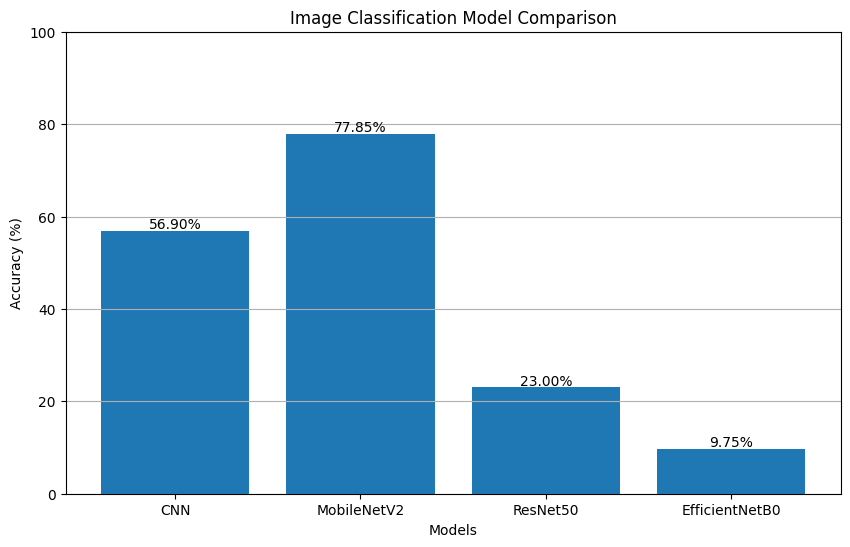


Best Model: MobileNetV2
Best Accuracy: 77.85 %


In [1]:
!pip install tensorflow matplotlib pandas

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import gc

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Use subset to reduce memory usage
X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)
IMG_SIZE = 96
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

results = {}
print("\nTraining CNN...")

cnn = models.Sequential([
    layers.Input(shape=(96,96,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')])

cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

cnn.fit(train_ds,epochs=5,validation_data=test_ds,verbose=1)

loss, acc = cnn.evaluate(test_ds, verbose=0)
results["CNN"] = acc * 100

tf.keras.backend.clear_session()
gc.collect()

def train_pretrained(base_model_fn, model_name):

    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(96,96,3))

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')])

    model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])

    model.fit(
        train_ds,
        epochs=3,
        validation_data=test_ds,
        verbose=1)

    loss, acc = model.evaluate(test_ds, verbose=0)

    results[model_name] = acc * 100

    tf.keras.backend.clear_session()
    gc.collect()
train_pretrained(
    MobileNetV2,
    "MobileNetV2")

train_pretrained(ResNet50,"ResNet50")

train_pretrained(EfficientNetB0,"EfficientNetB0")
print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():
    print(f"{model:15s} : {accuracy:.2f}%")

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,6))

bars = plt.bar(model_names, accuracies)

plt.title("Image Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,y + 0.5,f"{y:.2f}%",ha='center')
plt.ylim(0,100)
plt.grid(axis='y')
plt.show()

best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", round(results[best_model],2), "%")



TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Shape: (10000, 28, 28, 3)
Testing Shape: (2000, 28, 28, 3)


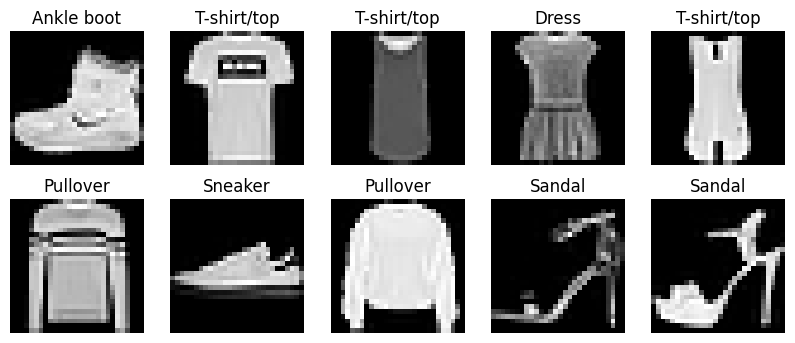


Training CNN...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7640 - loss: 0.6648 - val_accuracy: 0.8465 - val_loss: 0.4325
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8532 - loss: 0.4053 - val_accuracy: 0.8660 - val_loss: 0.3749
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8765 - loss: 0.3383 - val_accuracy: 0.8755 - val_loss: 0.3713
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8965 - loss: 0.2844 - val_accuracy: 0.8845 - val_loss: 0.3536
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9043 - loss: 0.2522 - val_accuracy: 0.8710 - val_loss: 0.3847

Training MobileNetV2...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.7950 - loss: 0.5902 - val_accuracy: 0.8620 - val_loss: 0.3836
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8604 - loss: 0.3947 - val_accuracy: 0.8635 - val_loss: 0.3697
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accura

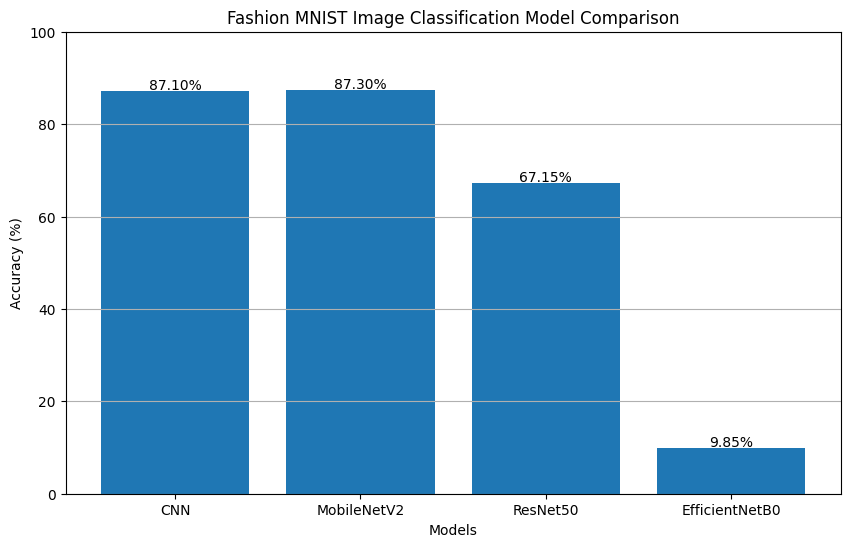


Best Model: MobileNetV2
Best Accuracy: 87.3 %


In [2]:
!pip install tensorflow matplotlib pandas

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import gc

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Load Fashion MNIST Dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Use subset to reduce memory usage
X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Convert grayscale 28x28 images to RGB 28x28x3
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

X_train = np.repeat(X_train, 3, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

IMG_SIZE = 96
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# Show sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")
plt.show()

results = {}

print("\nTraining CNN...")

cnn = models.Sequential([
    layers.Input(shape=(96, 96, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    verbose=1
)

loss, acc = cnn.evaluate(test_ds, verbose=0)
results["CNN"] = acc * 100

tf.keras.backend.clear_session()
gc.collect()

def train_pretrained(base_model_fn, model_name):
    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(96, 96, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_ds,
        epochs=3,
        validation_data=test_ds,
        verbose=1
    )

    loss, acc = model.evaluate(test_ds, verbose=0)
    results[model_name] = acc * 100

    tf.keras.backend.clear_session()
    gc.collect()

train_pretrained(MobileNetV2, "MobileNetV2")
train_pretrained(ResNet50, "ResNet50")
train_pretrained(EfficientNetB0, "EfficientNetB0")

print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():
    print(f"{model:15s} : {accuracy:.2f}%")

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies)

plt.title("Fashion MNIST Image Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y + 0.5,
        f"{y:.2f}%",
        ha='center'
    )

plt.ylim(0, 100)
plt.grid(axis='y')
plt.show()

best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", round(results[best_model], 2), "%")

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.2JWOH6_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Classes: ['cat', 'dog']


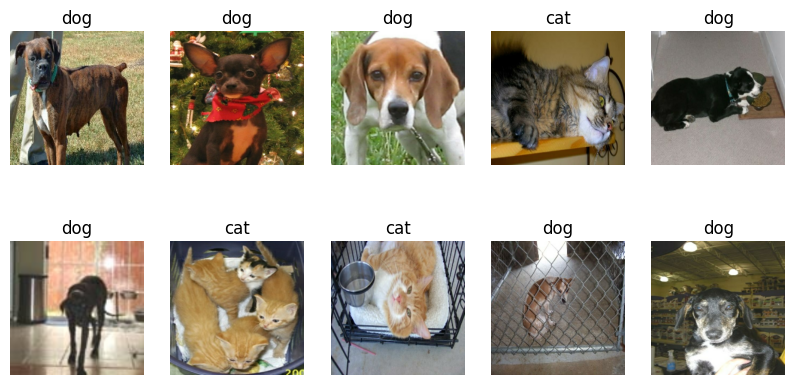


Training CNN...
Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 50s 79ms/step - accuracy: 0.6059 - loss: 0.6718 - val_accuracy: 0.5875 - val_loss: 0.6721
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.6980 - loss: 0.5726 - val_accuracy: 0.7214 - val_loss: 0.5533
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 40s 68ms/step - accuracy: 0.7758 - loss: 0.4696 - val_accuracy: 0.7599 - val_loss: 0.5390
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.8389 - loss: 0.3638 - val_accuracy: 0.7687 - val_loss: 0.5280
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 40s 69ms/step - accuracy: 0.8917 - loss: 0.2587 - val_accuracy: 0.7479 - val_loss: 0.6773

Training MobileNetV2...
Epoch 1/3
582/582 ━━━━━━━━━━━━━━━━━━━━ 76s 114ms/step - accuracy: 0.9777 - loss: 0.0625 - val_accuracy: 0.9839 - val_loss: 0.0414
Epoch 2/3
582/582 ━━━━━━━━━━━━━━━━━━━━ 38s 64ms/step - accuracy: 0.9860 - loss: 0.0394 - val_accuracy: 0.9832 - val_loss: 0.0464
Epoch 3/3
582/582 ━━━━━━━━━━━━━━━━━━━━ 40s 69ms/step -

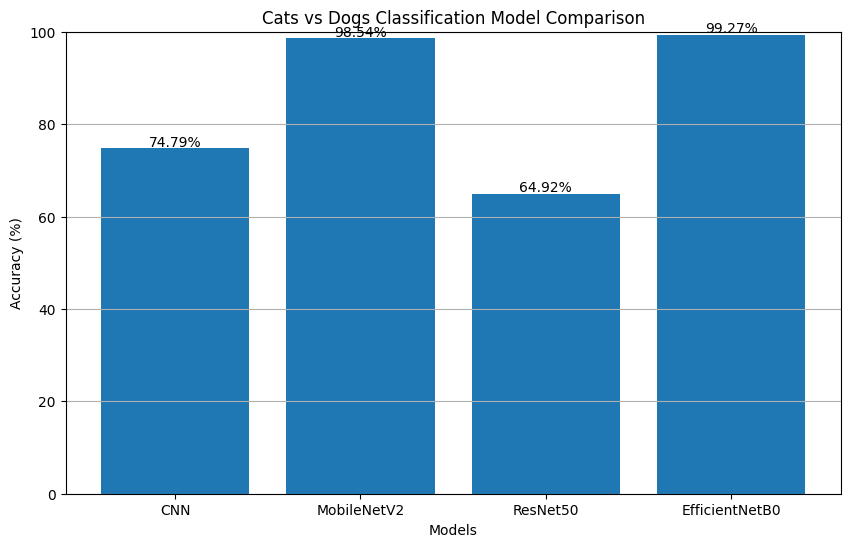


Best Model: EfficientNetB0
Best Accuracy: 99.27 %


In [5]:
!pip install tensorflow matplotlib pandas tensorflow-datasets

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import gc

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load Cats vs Dogs dataset
(ds_train, ds_test), ds_info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

class_names = ["cat", "dog"]
num_classes = 2

print("Classes:", class_names)

# Preprocessing for normal CNN, MobileNetV2, ResNet50
def preprocess_normal(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Preprocessing for EfficientNetB0
def preprocess_efficientnet(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

train_ds = ds_train.map(preprocess_normal).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = ds_test.map(preprocess_normal).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds_eff = ds_train.map(preprocess_efficientnet).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds_eff = ds_test.map(preprocess_efficientnet).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Show sample images
plt.figure(figsize=(10, 5))

for images, labels in train_ds.take(1):
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.show()

results = {}

# CNN Model
print("\nTraining CNN...")

cnn = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    verbose=1
)

loss, acc = cnn.evaluate(test_ds, verbose=0)
results["CNN"] = acc * 100

tf.keras.backend.clear_session()
gc.collect()

# Function for pretrained models
def train_pretrained(base_model_fn, model_name, train_data, test_data):
    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_data,
        epochs=3,
        validation_data=test_data,
        verbose=1
    )

    loss, acc = model.evaluate(test_data, verbose=0)
    results[model_name] = acc * 100

    tf.keras.backend.clear_session()
    gc.collect()

# Train pretrained models
train_pretrained(MobileNetV2, "MobileNetV2", train_ds, test_ds)
train_pretrained(ResNet50, "ResNet50", train_ds, test_ds)
train_pretrained(EfficientNetB0, "EfficientNetB0", train_ds_eff, test_ds_eff)

# Accuracy comparison
print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():
    print(f"{model:15s} : {accuracy:.2f}%")

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies)

plt.title("Cats vs Dogs Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y + 0.5,
        f"{y:.2f}%",
        ha='center'
    )

plt.ylim(0, 100)
plt.grid(axis='y')
plt.show()

best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", round(results[best_model], 2), "%")